<a href="https://colab.research.google.com/github/shahananasrin47-web/student-result-prediction/blob/main/Pandasassignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from geopy.distance import geodesic
import datetime
import time

### The beginning


#### Download individual file from https://s3.amazonaws.com/tripdata/index.html
The file title is 'YYYYMM-citibike-tripdata.csv.zip'
The LAST STUDENT digit from internal KTU code use for a Year definition i.e.
*   {0,1}==2017 # url = "https://s3.amazonaws.com/tripdata/2017-citibike-tripdata.zip"
*   {2,3}==2018 # url = "https://s3.amazonaws.com/tripdata/2018-citibike-tripdata.zip"
*   {4,5}==2019 # url = "https://s3.amazonaws.com/tripdata/2019-citibike-tripdata.zip"
*   {6,7}==2014 # url = "https://s3.amazonaws.com/tripdata/2014-citibike-tripdata.zip"
*   {8,9}==2015 # url = "https://s3.amazonaws.com/tripdata/2015-citibike-tripdata.zip"

Prefinal internal KTU code number - for mont definition MM=0x. if x=0, then MM=10
> Dowload file: 'YYYYMM-citibike-tripdata.zip'


In [2]:
!mkdir 'data'
import urllib
import zipfile

url = "https://s3.amazonaws.com/tripdata/2019-citibike-tripdata.zip"
extract_dir = 'data'

zip_path, _ = urllib.request.urlretrieve(url)
with zipfile.ZipFile(zip_path, "r") as f:
    f.extractall(extract_dir)


In [3]:
citybike = pd.read_csv('/content/data/2019-citibike-tripdata/10_October/201910-citibike-tripdata_1.csv')

In [5]:
citybike.head()

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender
0,527,2019-10-01 00:00:05.6180,2019-10-01 00:08:52.9430,3746,6 Ave & Broome St,40.724308,-74.004730,223,W 13 St & 7 Ave,40.737815,-73.999947,41750,Subscriber,1993,1
1,174,2019-10-01 00:00:15.8750,2019-10-01 00:03:10.1680,3301,Columbus Ave & W 95 St,40.791956,-73.968087,3283,W 89 St & Columbus Ave,40.788221,-73.970416,18264,Subscriber,1992,1
2,759,2019-10-01 00:00:19.8240,2019-10-01 00:12:59.7070,161,LaGuardia Pl & W 3 St,40.729170,-73.998102,174,E 25 St & 1 Ave,40.738177,-73.977387,25525,Subscriber,1995,1
3,615,2019-10-01 00:00:21.0680,2019-10-01 00:10:36.6790,254,W 11 St & 6 Ave,40.735324,-73.998004,477,W 41 St & 8 Ave,40.756405,-73.990026,30186,Subscriber,1992,1
4,761,2019-10-01 00:00:26.3800,2019-10-01 00:13:08.3130,161,LaGuardia Pl & W 3 St,40.729170,-73.998102,174,E 25 St & 1 Ave,40.738177,-73.977387,25597,Subscriber,1992,1


1. Find the total number of records and columns as well as statistics "describe" of the data.

In [42]:
print('total number of records =', citybike.shape[0])

total number of records = 1000000


In [43]:
citybike.describe()

,tripduration,start station id,start station latitude,start station longitude,end station id,end station latitude,end station longitude,bikeid,birth year,gender,distance_km
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,9.486911e+02,1662.884247,40.738027,-73.981938,1649.701293,40.737557,-73.982232,31697.720849,1980.771833,1.167504,1.783014
std,9.417797e+03,1485.272240,0.030060,0.019830,1484.288391,0.029842,0.019923,8335.232508,12.154873,0.549171,1.382950
min,6.100000e+01,72.000000,40.655400,-74.025353,72.000000,40.655400,-74.062500,14529.000000,1885.000000,0.000000,0.000000
25%,3.750000e+02,379.000000,40.718822,-73.995101,377.000000,40.718502,-73.995653,26399.000000,1970.000000,1.000000,0.844662
50%,6.290000e+02,509.000000,40.739017,-73.985180,507.000000,40.737815,-73.986022,32811.000000,1984.000000,1.000000,1.393585
75%,1.083000e+03,3301.000000,40.757632,-73.971214,3301.000000,40.757148,-73.971879,39553.000000,1991.000000,1.000000,2.304084
max,2.946638e+06,3861.000000,40.814394,-73.907744,3870.000000,40.814394,-73.907744,42068.000000,2003.000000,2.000000,16.925768


2. Scatter plot data detween 'birth year' and 'tripduration' (use a **DF.plot.scatter**, s = 100) as well as **DF.plot.hist** of 'birth year' collumn into number of bins from your internal code 2 last digits xxxXX (bins=XX).

<Axes: xlabel='birth year', ylabel='tripduration'>

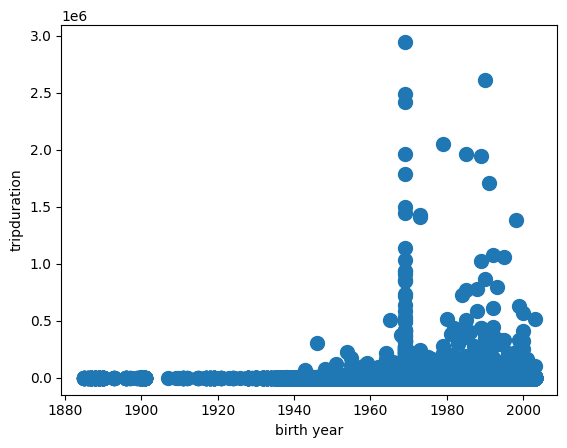

In [44]:
citybike.plot.scatter(x='birth year', y='tripduration', s=100)

<Axes: ylabel='Frequency'>

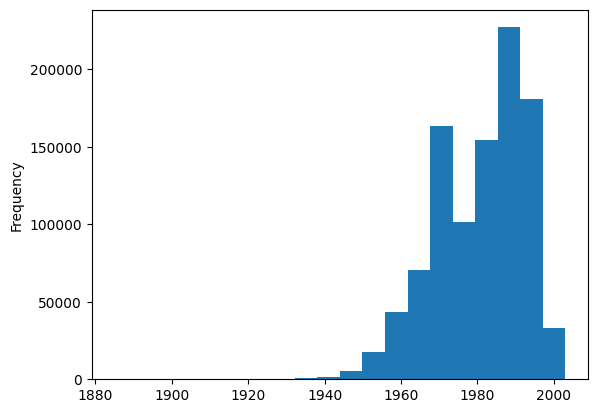

In [45]:
citybike['birth year'].plot.hist(bins=20)

Find average trip duration in minutes (column: tripduration) with 2 numbers precision (use 'round' function).

In [12]:
print('Average TRip Duration =', round(citybike['tripduration'].mean()/60, 2), 'min')

Average TRip Duration = 15.81 min


How many trips have started and ended at the same station?

In [17]:
citybike[citybike['start station id'] == citybike['end station id']].shape[0]

20352

How many trips have stared and ended at the same station with the UNIQUE bike_ID? (i.e. DF.unique().shape)

In [21]:
citybike[citybike['start station id'] == citybike['end station id']]['bikeid'].unique().shape[0]

10335

Which bike was most offten used (bikeid) in a town and how many times?

In [24]:
citybike['bikeid'].value_counts().head(1)

,count
bikeid,
40199,195


Find a bike (bikeid), who had the longest trip duration on average. (i.e. use a **DF.mean()** and **sort_values()**)

In [27]:
citybike.groupby('bikeid')['tripduration'].mean().sort_values(ascending=False).head(1)

,tripduration
bikeid,
30165,2055354.0


Find the number of missing records (i.e. null) in the column 'start station id'.

In [30]:
print('the mumber of missing rec =', citybike['start station id'].isnull().sum())

the mumber of missing rec = 0


Find the average distance between stations (apriory removing lines: start station id = end station id).

Hint: use the library **geopy** and distance measure **geodesic** (min distance between two geo locations) p.s.: https://geopy.readthedocs.io/en/stable/#module-geopy.distance


In [32]:
citybike['distance_km'] = citybike.apply(lambda x: geodesic((x['start station latitude'], x['start station longitude']),
                                                            (x['end station latitude'], x['end station longitude'])).kilometers, axis=1)




In [37]:
print('Average trip duration =', citybike[citybike['start station id'] != citybike['end station id']]['distance_km'].mean().round(2), 'km')

Average trip duration = 1.82 km


Conclusions: